## TASK 4: Disease Prediction from Medical Data

## Resources

### Objective
Predict the possibility of diseases based on patient data using classification techniques. We will use features like symptoms, age, and blood test results, and apply algorithms such as SVM, Logistic Regression, Random Forest, and XGBoost.

We will start by loading the Heart Disease dataset.

In [1]:
# Download the Heart Disease dataset (UCI Statlog Heart Dataset)
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=145)

# data (as pandas DataFrames)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)

# Display the first few rows of the features and target
print("\nFeatures (X) head:")
display(X.head())
print("\nTargets (y) head:")
display(y.head())

{'uci_id': 145, 'name': 'Statlog (Heart)', 'repository_url': 'https://archive.ics.uci.edu/dataset/145/statlog+heart', 'data_url': 'https://archive.ics.uci.edu/static/public/145/data.csv', 'abstract': 'This dataset is a heart disease database similar to a database already present in the repository (Heart Disease databases) but in a slightly different form', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 270, 'num_features': 13, 'feature_types': ['Categorical', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['heart-disease'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': None, 'last_updated': 'Fri Feb 09 2024', 'dataset_doi': '10.24432/C57303', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': 'Cost Matrix\r\n\r\n_______\t abse  pres\r\nabsence\t 0\t1\r\npresence  5\t0\r\n\r\nwhere the rows represent the true values and the columns the p

,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0



Targets (y) head:


,heart-disease
0,2
1,1
2,2
3,1
4,1


In [2]:
print("Missing values in features (X):")
display(X.isnull().sum())

print("\nMissing values in target (y):")
display(y.isnull().sum())

Missing values in features (X):


,0
age,0
sex,0
chest-pain,0
rest-bp,0
serum-chol,0
fasting-blood-sugar,0
electrocardiographic,0
max-heart-rate,0
angina,0
oldpeak,0



Missing values in target (y):


,0
heart-disease,0


### Data Preprocessing

Based on the `variable_info` from the dataset metadata, we have several categorical features (`chest-pain`, `restecg`, `thal`) and binary features (`sex`, `fbs`, `exang`). We also need to ensure the target variable `heart-disease` is binary (0 or 1).

Let's apply one-hot encoding to the nominal categorical variables and convert the target.

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# # Reload X to ensure it's in its original state before preprocessing
# X = heart_disease.data.features
# y = heart_disease.data.targets

# Identify categorical columns for one-hot encoding based on heart_disease.variables output
categorical_cols = ['chest-pain', 'electrocardiographic', 'thal']

# Separate and one-hot encode the categorical columns
encoded_features = pd.get_dummies(X[categorical_cols], drop_first=True)

# Drop the original categorical columns from X
X = X.drop(columns=categorical_cols)

# Concatenate the one-hot encoded features back to X
X = pd.concat([X, encoded_features], axis=1)

# Standardize the target variable 'heart-disease'
# Original target values are 1 (absence) and 2 (presence)
# We'll map them to 0 (absence) and 1 (presence) for binary classification.
y = y['heart-disease'].apply(lambda x: 1 if x == 2 else 0)

print("\nFeatures (X) after one-hot encoding and target (y) after conversion:")
display(X.head())
display(y.head())


Features (X) after one-hot encoding and target (y) after conversion:


,age,sex,rest-bp,serum-chol,fasting-blood-sugar,max-heart-rate,angina,oldpeak,slope,major-vessels,chest-pain,electrocardiographic,thal
0,70.0,1.0,130.0,322.0,0.0,109.0,0.0,2.4,2.0,3.0,4.0,2.0,3.0
1,67.0,0.0,115.0,564.0,0.0,160.0,0.0,1.6,2.0,0.0,3.0,2.0,7.0
2,57.0,1.0,124.0,261.0,0.0,141.0,0.0,0.3,1.0,0.0,2.0,0.0,7.0
3,64.0,1.0,128.0,263.0,0.0,105.0,1.0,0.2,2.0,1.0,4.0,0.0,7.0
4,74.0,0.0,120.0,269.0,0.0,121.0,1.0,0.2,1.0,1.0,2.0,2.0,3.0


,heart-disease
0,1
1,0
2,1
3,0
4,0


### Data Splitting and Scaling

We will split the data into training and testing sets to evaluate our models on unseen data. Then, we'll apply `StandardScaler` to normalize the numerical features, which is often beneficial for algorithms like SVM and Logistic Regression.

In [9]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize StandardScaler
scaler = StandardScaler()

# Identify numerical columns for scaling (all columns in X are numerical after one-hot encoding)
numerical_cols = X.columns

# Apply scaling to training and testing sets
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nScaled X_train head:")
display(X_train.head())


Shape of X_train: (189, 13)
Shape of X_test: (81, 13)
Shape of y_train: (189,)
Shape of y_test: (81,)

Scaled X_train head:


,age,sex,rest-bp,serum-chol,fasting-blood-sugar,max-heart-rate,angina,oldpeak,slope,major-vessels,chest-pain,electrocardiographic,thal
84,0.246885,0.665393,-1.218091,-0.964008,-0.399386,-1.021941,1.303840,0.288833,0.638691,-0.724139,0.818039,-1.046039,0.626060
251,-1.180400,0.665393,-0.101064,-0.620599,-0.399386,1.695350,-0.766965,-0.968987,-0.992560,-0.724139,-1.257255,0.961082,-0.917313
92,-0.082489,0.665393,-0.436172,0.276080,-0.399386,-1.767005,1.303840,0.875815,0.638691,0.312696,0.818039,0.961082,1.140517
201,0.356676,0.665393,-0.380321,0.924741,-0.399386,0.950287,-0.766965,-0.968987,-0.992560,1.349531,0.818039,0.961082,1.140517
126,0.795841,0.665393,-0.659578,0.295158,-0.399386,-2.205277,1.303840,0.540396,0.638691,1.349531,0.818039,-1.046039,1.140517


### Model Training and Evaluation

We will now train several classification models, including Support Vector Machine (SVM), Logistic Regression, Random Forest, and XGBoost. After training, we will evaluate their performance using common metrics like accuracy, precision, recall, and F1-score.

In [10]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize models
models = {
    'SVM': SVC(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }
    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

# Display results in a DataFrame for better comparison
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
display(results_df.round(4))


Training SVM...
SVM - Accuracy: 0.8272, Precision: 0.8214, Recall: 0.7188, F1-Score: 0.7667

Training Logistic Regression...
Logistic Regression - Accuracy: 0.8272, Precision: 0.8750, Recall: 0.6562, F1-Score: 0.7500

Training Random Forest...
Random Forest - Accuracy: 0.8395, Precision: 0.9524, Recall: 0.6250, F1-Score: 0.7547

Training XGBoost...
XGBoost - Accuracy: 0.7778, Precision: 0.7917, Recall: 0.5938, F1-Score: 0.6786

Model Performance Comparison:


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Accuracy,Precision,Recall,F1-Score
SVM,0.8272,0.8214,0.7188,0.7667
Logistic Regression,0.8272,0.8750,0.6562,0.7500
Random Forest,0.8395,0.9524,0.6250,0.7547
XGBoost,0.7778,0.7917,0.5938,0.6786


### Model Optimization (Hyperparameter Tuning)

Now, let's optimize the Random Forest Classifier, which showed the best performance in the initial evaluation. We'll use `GridSearchCV` to find the optimal hyperparameters.

In [11]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1  # Use all available cores
)

print("Starting GridSearchCV for Random Forest...")

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

print("GridSearchCV for Random Forest completed.")

# Get the best parameters and best score
best_params_rf = grid_search_rf.best_params_
best_score_rf = grid_search_rf.best_score_

print(f"Best parameters for Random Forest: {best_params_rf}")
print(f"Best cross-validation accuracy for Random Forest: {best_score_rf:.4f}")

# Evaluate the best model on the test set
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf_optimized = best_rf_model.predict(X_test)

accuracy_rf_optimized = accuracy_score(y_test, y_pred_rf_optimized)
precision_rf_optimized = precision_score(y_test, y_pred_rf_optimized)
recall_rf_optimized = recall_score(y_test, y_pred_rf_optimized)
f1_rf_optimized = f1_score(y_test, y_pred_rf_optimized)

print(f"\nOptimized Random Forest - Accuracy: {accuracy_rf_optimized:.4f}")
print(f"Optimized Random Forest - Precision: {precision_rf_optimized:.4f}")
print(f"Optimized Random Forest - Recall: {recall_rf_optimized:.4f}")
print(f"Optimized Random Forest - F1-Score: {f1_rf_optimized:.4f}")

# Update results_df with optimized Random Forest performance
optimized_rf_results = {
    'Accuracy': accuracy_rf_optimized,
    'Precision': precision_rf_optimized,
    'Recall': recall_rf_optimized,
    'F1-Score': f1_rf_optimized
}

results_df.loc['Random Forest (Optimized)'] = optimized_rf_results

print("\nUpdated Model Performance Comparison:")
display(results_df.round(4))

Starting GridSearchCV for Random Forest...
GridSearchCV for Random Forest completed.
Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best cross-validation accuracy for Random Forest: 0.8521

Optimized Random Forest - Accuracy: 0.8148
Optimized Random Forest - Precision: 0.9048
Optimized Random Forest - Recall: 0.5938
Optimized Random Forest - F1-Score: 0.7170

Updated Model Performance Comparison:


,Accuracy,Precision,Recall,F1-Score
SVM,0.8272,0.8214,0.7188,0.7667
Logistic Regression,0.8272,0.8750,0.6562,0.7500
Random Forest,0.8395,0.9524,0.6250,0.7547
XGBoost,0.7778,0.7917,0.5938,0.6786
Random Forest (Optimized),0.8148,0.9048,0.5938,0.7170


### Feature Importance of Optimized Random Forest Model

Top 10 Feature Importances (Optimized Random Forest):


,Feature,Importance
7,oldpeak,0.187227
10,chest-pain,0.123874
12,thal,0.112290
5,max-heart-rate,0.100208
9,major-vessels,0.096639
6,angina,0.092045
8,slope,0.074613
2,rest-bp,0.064947
0,age,0.063912
3,serum-chol,0.050963


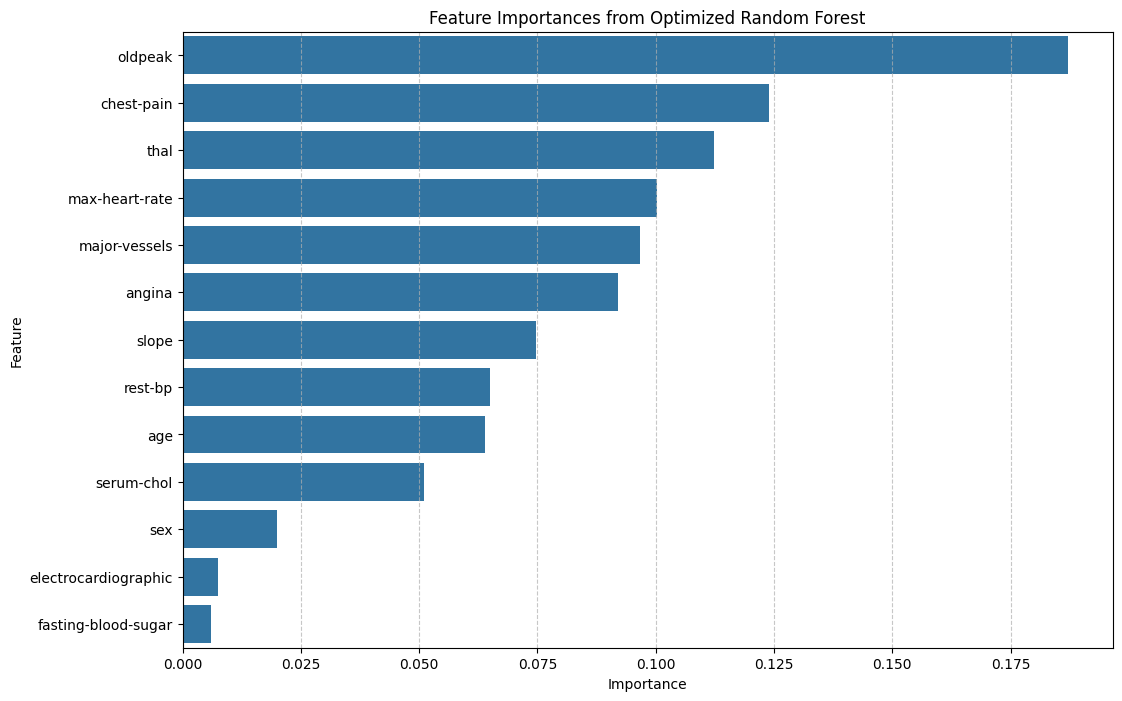

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best Random Forest model
feature_importances = best_rf_model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances (Optimized Random Forest):")
display(features_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Feature Importances from Optimized Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Final Model Performance Comparison

In [13]:
print("Final Model Performance Comparison (Optimized Random Forest vs. Baseline Models):")
display(results_df.round(4))

Final Model Performance Comparison (Optimized Random Forest vs. Baseline Models):


,Accuracy,Precision,Recall,F1-Score
SVM,0.8272,0.8214,0.7188,0.7667
Logistic Regression,0.8272,0.8750,0.6562,0.7500
Random Forest,0.8395,0.9524,0.6250,0.7547
XGBoost,0.7778,0.7917,0.5938,0.6786
Random Forest (Optimized),0.8148,0.9048,0.5938,0.7170


### Confusion Matrix for Optimized Random Forest Model

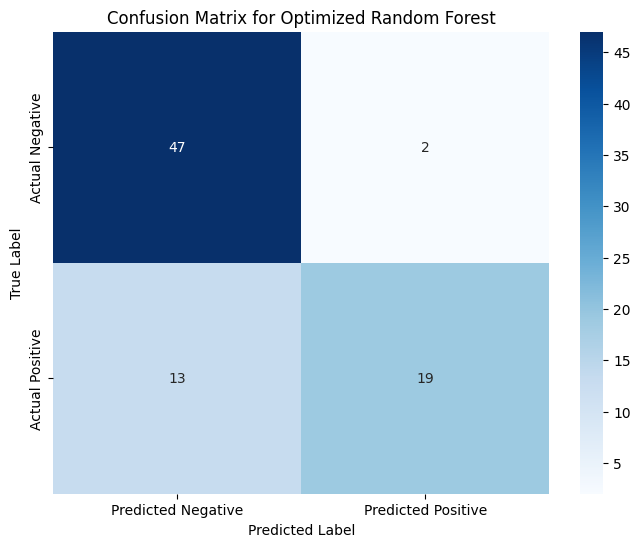

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from the optimized Random Forest model
y_pred_rf_optimized = best_rf_model.predict(X_test)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_rf_optimized)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for Optimized Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### ROC Curve for Optimized Random Forest Model

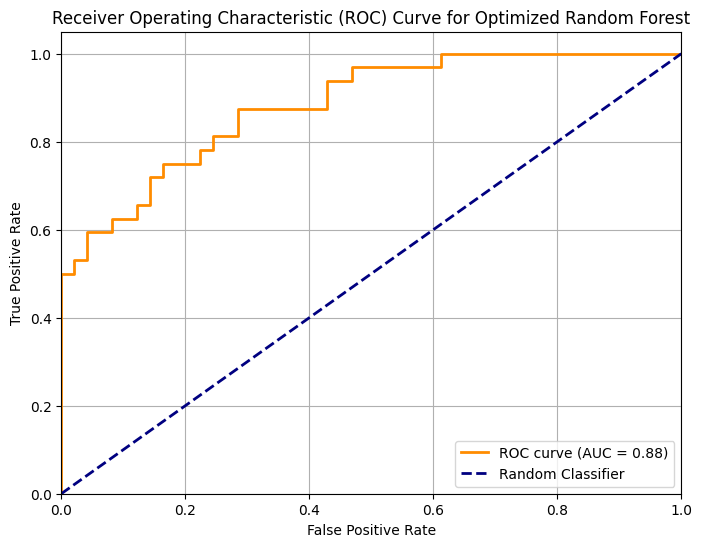

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for the positive class
y_pred_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

# Calculate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_rf)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba_rf)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Optimized Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Feature Engineering and Selection

We will explore creating polynomial features to capture non-linear relationships and interactions. Then, we'll use `SelectKBest` with an appropriate scoring function to select the most informative features from the combined set (original + polynomial).

In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif

# Combine X_train and X_test temporarily to fit PolynomialFeatures on the entire dataset
X_combined = pd.concat([X_train, X_test], axis=0)

# Identify numerical features for polynomial transformation
# All features in X are numerical after one-hot encoding and scaling
numerical_features_for_poly = X_combined.columns.tolist()

# Generate polynomial features (degree 2 for interactions and squared terms)
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly_combined = poly.fit_transform(X_combined[numerical_features_for_poly])

# Create a DataFrame with meaningful column names for polynomial features
poly_feature_names = poly.get_feature_names_out(numerical_features_for_poly)
X_poly_combined_df = pd.DataFrame(X_poly_combined, columns=poly_feature_names, index=X_combined.index)

print(f"Original number of features: {X_combined.shape[1]}")
print(f"Number of features after polynomial expansion: {X_poly_combined_df.shape[1]}")

# Split back into training and testing sets
X_train_poly = X_poly_combined_df.loc[X_train.index]
X_test_poly = X_poly_combined_df.loc[X_test.index]

# Apply feature selection using SelectKBest
# We'll select a reasonable number of top features, e.g., 20, using f_classif for classification
k_best_features = min(20, X_train_poly.shape[1]) # Ensure k is not greater than the number of features
selector = SelectKBest(score_func=f_classif, k=k_best_features)

# Fit on training data and transform both training and testing data
X_train_selected = selector.fit_transform(X_train_poly, y_train)
X_test_selected = selector.transform(X_test_poly)

# Get the names of the selected features
selected_feature_names = X_train_poly.columns[selector.get_support()].tolist()

print(f"\nNumber of features selected: {len(selected_feature_names)}")
print("Selected features:", selected_feature_names)

# Convert back to DataFrame for model training (optional but good for consistency)
X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_feature_names, index=X_train.index)
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_feature_names, index=X_test.index)

print("\nShape of X_train after feature selection:", X_train_selected_df.shape)
print("Shape of X_test after feature selection:", X_test_selected_df.shape)

display(X_train_selected_df.head())

Original number of features: 13
Number of features after polynomial expansion: 104

Number of features selected: 20
Selected features: ['age', 'sex', 'rest-bp', 'max-heart-rate', 'angina', 'oldpeak', 'slope', 'major-vessels', 'chest-pain', 'thal', 'age max-heart-rate', 'age thal', 'sex^2', 'sex rest-bp', 'angina^2', 'oldpeak^2', 'major-vessels^2', 'major-vessels electrocardiographic', 'electrocardiographic^2', 'thal^2']

Shape of X_train after feature selection: (189, 20)
Shape of X_test after feature selection: (81, 20)


,age,sex,rest-bp,max-heart-rate,angina,oldpeak,slope,major-vessels,chest-pain,thal,age max-heart-rate,age thal,sex^2,sex rest-bp,angina^2,oldpeak^2,major-vessels^2,major-vessels electrocardiographic,electrocardiographic^2,thal^2
84,0.246885,0.665393,-1.218091,-1.021941,1.303840,0.288833,0.638691,-0.724139,0.818039,0.626060,-0.252302,0.154565,0.442748,-0.810509,1.700000,0.083424,0.524377,0.757477,1.094198,0.391951
251,-1.180400,0.665393,-0.101064,1.695350,-0.766965,-0.968987,-0.992560,-0.724139,-1.257255,-0.917313,-2.001192,1.082797,0.442748,-0.067248,0.588235,0.938935,0.524377,-0.695956,0.923678,0.841464
92,-0.082489,0.665393,-0.436172,-1.767005,1.303840,0.875815,0.638691,0.312696,0.818039,1.140517,0.145758,-0.094080,0.442748,-0.290226,1.700000,0.767052,0.097779,0.300527,0.923678,1.300779
201,0.356676,0.665393,-0.380321,0.950287,-0.766965,-0.968987,-0.992560,1.349531,0.818039,1.140517,0.338945,0.406795,0.442748,-0.253063,0.588235,0.938935,1.821235,1.297010,0.923678,1.300779
126,0.795841,0.665393,-0.659578,-2.205277,1.303840,0.540396,0.638691,1.349531,0.818039,1.140517,-1.755049,0.907670,0.442748,-0.438878,1.700000,0.292028,1.821235,-1.411663,1.094198,1.300779


Now, let's retrain the optimized Random Forest model with these newly engineered and selected features.

In [21]:
# Retrain the optimized Random Forest model with the selected features
best_rf_model_fe = RandomForestClassifier(
    n_estimators=best_params_rf['n_estimators'],
    max_depth=best_params_rf['max_depth'],
    min_samples_split=best_params_rf['min_samples_split'],
    min_samples_leaf=best_params_rf['min_samples_leaf'],
    class_weight='balanced', # Added class_weight parameter
    random_state=42
)

print("\nTraining Optimized Random Forest with Feature Engineered & Selected Data (with class_weight='balanced')...")
best_rf_model_fe.fit(X_train_selected_df, y_train)

y_pred_rf_fe_optimized = best_rf_model_fe.predict(X_test_selected_df)

accuracy_rf_fe_optimized = accuracy_score(y_test, y_pred_rf_fe_optimized)
precision_rf_fe_optimized = precision_score(y_test, y_pred_rf_fe_optimized)
recall_rf_fe_optimized = recall_score(y_test, y_pred_rf_fe_optimized)
f1_rf_fe_optimized = f1_score(y_test, y_pred_rf_fe_optimized)

print(f"Optimized Random Forest (FE + Class Weight) - Accuracy: {accuracy_rf_fe_optimized:.4f}")
print(f"Optimized Random Forest (FE + Class Weight) - Precision: {precision_rf_fe_optimized:.4f}")
print(f"Optimized Random Forest (FE + Class Weight) - Recall: {recall_rf_fe_optimized:.4f}")
print(f"Optimized Random Forest (FE + Class Weight) - F1-Score: {f1_rf_fe_optimized:.4f}")

# Update results_df with feature engineered and optimized Random Forest performance
fe_optimized_rf_results_cw = {
    'Accuracy': accuracy_rf_fe_optimized,
    'Precision': precision_rf_fe_optimized,
    'Recall': recall_rf_fe_optimized,
    'F1-Score': f1_rf_fe_optimized
}

results_df.loc['Random Forest (FE Optimized + CW)'] = fe_optimized_rf_results_cw

print("\nUpdated Model Performance Comparison with Feature Engineering and Class Weight:")
display(results_df.round(4))


Training Optimized Random Forest with Feature Engineered & Selected Data (with class_weight='balanced')...
Optimized Random Forest (FE + Class Weight) - Accuracy: 0.7778
Optimized Random Forest (FE + Class Weight) - Precision: 0.7333
Optimized Random Forest (FE + Class Weight) - Recall: 0.6875
Optimized Random Forest (FE + Class Weight) - F1-Score: 0.7097

Updated Model Performance Comparison with Feature Engineering and Class Weight:


,Accuracy,Precision,Recall,F1-Score
SVM,0.8272,0.8214,0.7188,0.7667
Logistic Regression,0.8272,0.8750,0.6562,0.7500
Random Forest,0.8395,0.9524,0.6250,0.7547
XGBoost,0.7778,0.7917,0.5938,0.6786
Random Forest (Optimized),0.8148,0.9048,0.5938,0.7170
Random Forest (FE Optimized),0.7901,0.7586,0.6875,0.7213
Random Forest (FE Optimized + CW),0.7778,0.7333,0.6875,0.7097


### ROC Curve for Optimized Random Forest Model (Feature Engineered + Class Weight)

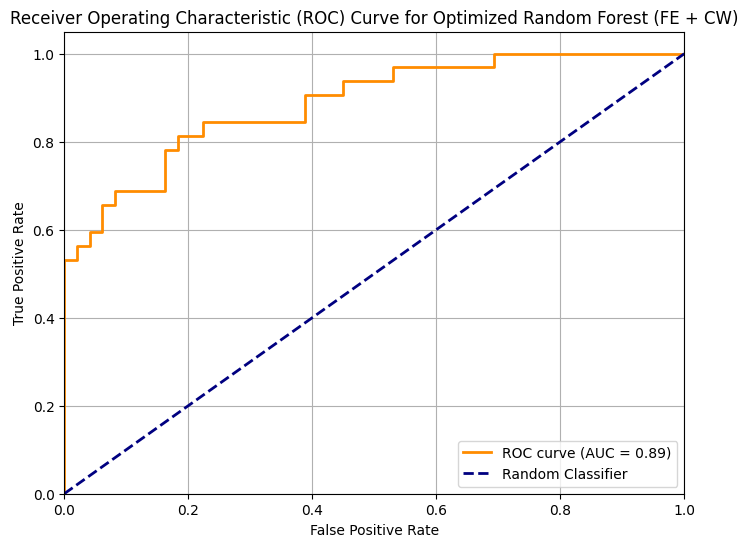

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class from the FE + CW optimized model
y_pred_proba_rf_fe_cw = best_rf_model_fe.predict_proba(X_test_selected_df)[:, 1]

# Calculate FPR, TPR, and thresholds
fpr_fe_cw, tpr_fe_cw, thresholds_fe_cw = roc_curve(y_test, y_pred_proba_rf_fe_cw)

# Calculate AUC score
auc_score_fe_cw = roc_auc_score(y_test, y_pred_proba_rf_fe_cw)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_fe_cw, tpr_fe_cw, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score_fe_cw:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Optimized Random Forest (FE + CW)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Precision-Recall Curve for Optimized Random Forest Model (Feature Engineered + Class Weight)

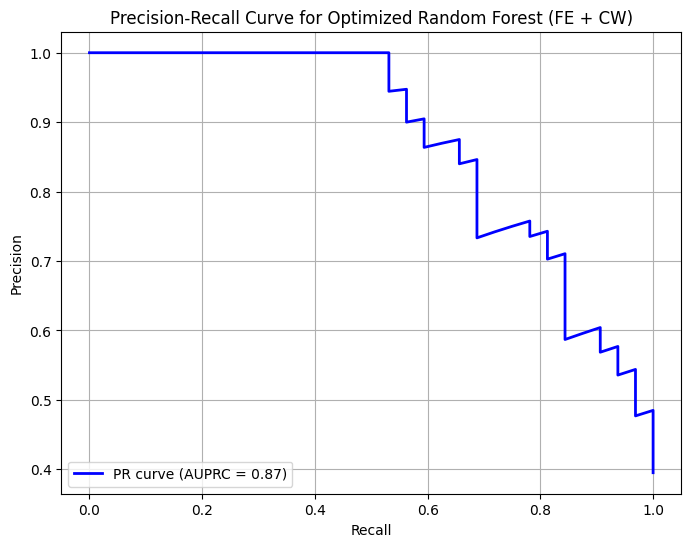

In [23]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class from the FE + CW optimized model
y_pred_proba_rf_fe_cw = best_rf_model_fe.predict_proba(X_test_selected_df)[:, 1]

# Calculate precision, recall, and thresholds
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_rf_fe_cw)

# Calculate AUPRC (Area Under the Precision-Recall Curve)
auprc = auc(recall, precision)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUPRC = {auprc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Optimized Random Forest (FE + CW)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

### Feature Importance of Optimized Random Forest Model (Feature Engineered + Class Weight)

Top 10 Feature Importances (Optimized Random Forest with FE + CW):


,Feature,Importance
5,oldpeak,0.118858
7,major-vessels,0.090187
9,thal,0.088834
3,max-heart-rate,0.082735
6,slope,0.074318
8,chest-pain,0.071493
19,thal^2,0.055319
11,age thal,0.054551
14,angina^2,0.046772
15,oldpeak^2,0.046119


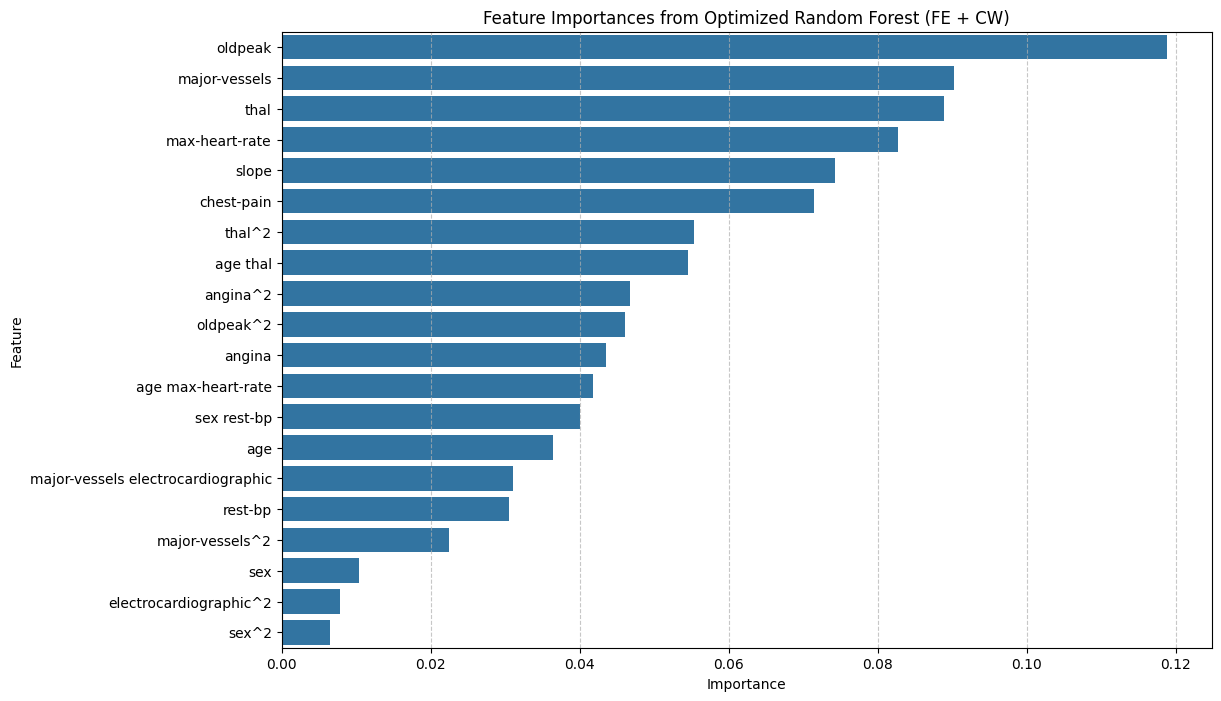

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best Random Forest model (FE + CW)
feature_importances_fe_cw = best_rf_model_fe.feature_importances_

# Create a DataFrame for better visualization
features_df_fe_cw = pd.DataFrame({
    'Feature': X_train_selected_df.columns,
    'Importance': feature_importances_fe_cw
})

# Sort features by importance
features_df_fe_cw = features_df_fe_cw.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances (Optimized Random Forest with FE + CW):")
display(features_df_fe_cw.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df_fe_cw)
plt.title('Feature Importances from Optimized Random Forest (FE + CW)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Feature Selection based on Importance

In [33]:
# Define a threshold for low importance (e.g., features with importance less than 0.005)
importance_threshold = 0.05

# Identify features to drop
low_importance_features = features_df_fe_cw[features_df_fe_cw['Importance'] < importance_threshold]['Feature'].tolist()

print(f"Features to be dropped (Importance < {importance_threshold}): {low_importance_features}")

# Drop these features from X_train_selected_df and X_test_selected_df
X_train_reduced_df = X_train_selected_df.drop(columns=low_importance_features, errors='ignore')
X_test_reduced_df = X_test_selected_df.drop(columns=low_importance_features, errors='ignore')

print(f"\nShape of X_train after dropping low importance features: {X_train_reduced_df.shape}")
print(f"Shape of X_test after dropping low importance features: {X_test_reduced_df.shape}")

print("\nRemaining features:")
display(X_train_reduced_df.columns.tolist())

# Retrain the optimized Random Forest model with the reduced feature set
best_rf_model_reduced = RandomForestClassifier(
    n_estimators=best_params_rf['n_estimators'],
    max_depth=best_params_rf['max_depth'],
    min_samples_split=best_params_rf['min_samples_split'],
    min_samples_leaf=best_params_rf['min_samples_leaf'],
    class_weight='balanced',
    random_state=42
)

print("\nTraining Optimized Random Forest with Reduced Feature Set (FE + CW)...")
best_rf_model_reduced.fit(X_train_reduced_df, y_train)

y_pred_rf_reduced = best_rf_model_reduced.predict(X_test_reduced_df)

accuracy_rf_reduced = accuracy_score(y_test, y_pred_rf_reduced)
precision_rf_reduced = precision_score(y_test, y_pred_rf_reduced)
recall_rf_reduced = recall_score(y_test, y_pred_rf_reduced)
f1_rf_reduced = f1_score(y_test, y_pred_rf_reduced)

print(f"Optimized Random Forest (FE + CW + Reduced Features) - Accuracy: {accuracy_rf_reduced:.4f}")
print(f"Optimized Random Forest (FE + CW + Reduced Features) - Precision: {precision_rf_reduced:.4f}")
print(f"Optimized Random Forest (FE + CW + Reduced Features) - Recall: {recall_rf_reduced:.4f}")
print(f"Optimized Random Forest (FE + CW + Reduced Features) - F1-Score: {f1_rf_reduced:.4f}")

# Update results_df with the performance of the model with reduced features
reduced_fe_optimized_rf_results_cw = {
    'Accuracy': accuracy_rf_reduced,
    'Precision': precision_rf_reduced,
    'Recall': recall_rf_reduced,
    'F1-Score': f1_rf_reduced
}

results_df.loc['Random Forest (FE Optimized + CW + Reduced)'] = reduced_fe_optimized_rf_results_cw

print("\nUpdated Model Performance Comparison with Reduced Features:")
display(results_df.round(4))

Features to be dropped (Importance < 0.05): ['angina^2', 'oldpeak^2', 'angina', 'age max-heart-rate', 'sex rest-bp', 'age', 'major-vessels electrocardiographic', 'rest-bp', 'major-vessels^2', 'sex', 'electrocardiographic^2', 'sex^2']

Shape of X_train after dropping low importance features: (189, 8)
Shape of X_test after dropping low importance features: (81, 8)

Remaining features:


['max-heart-rate',
 'oldpeak',
 'slope',
 'major-vessels',
 'chest-pain',
 'thal',
 'age thal',
 'thal^2']


Training Optimized Random Forest with Reduced Feature Set (FE + CW)...
Optimized Random Forest (FE + CW + Reduced Features) - Accuracy: 0.8148
Optimized Random Forest (FE + CW + Reduced Features) - Precision: 0.7742
Optimized Random Forest (FE + CW + Reduced Features) - Recall: 0.7500
Optimized Random Forest (FE + CW + Reduced Features) - F1-Score: 0.7619

Updated Model Performance Comparison with Reduced Features:


,Accuracy,Precision,Recall,F1-Score
SVM,0.8272,0.8214,0.7188,0.7667
Logistic Regression,0.8272,0.8750,0.6562,0.7500
Random Forest,0.8395,0.9524,0.6250,0.7547
XGBoost,0.7778,0.7917,0.5938,0.6786
Random Forest (Optimized),0.8148,0.9048,0.5938,0.7170
Random Forest (FE Optimized),0.7901,0.7586,0.6875,0.7213
Random Forest (FE Optimized + CW),0.7778,0.7333,0.6875,0.7097
Random Forest (FE Optimized + CW + Reduced),0.8148,0.7742,0.7500,0.7619


### Confusion Matrix for Optimized Random Forest Model (Feature Engineered + Class Weight + Reduced Features)

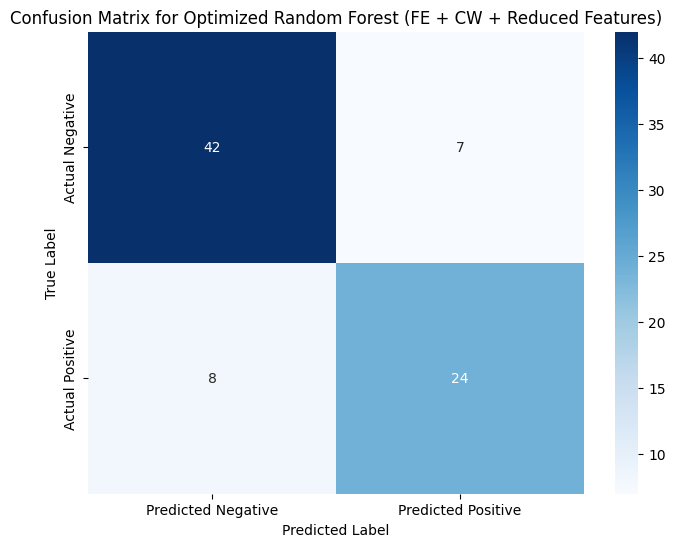

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from the reduced feature model
y_pred_rf_reduced = best_rf_model_reduced.predict(X_test_reduced_df)

# Calculate the confusion matrix
cm_reduced = confusion_matrix(y_test, y_pred_rf_reduced)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_reduced, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for Optimized Random Forest (FE + CW + Reduced Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### ROC Curve for Optimized Random Forest Model (Feature Engineered + Class Weight + Reduced Features)

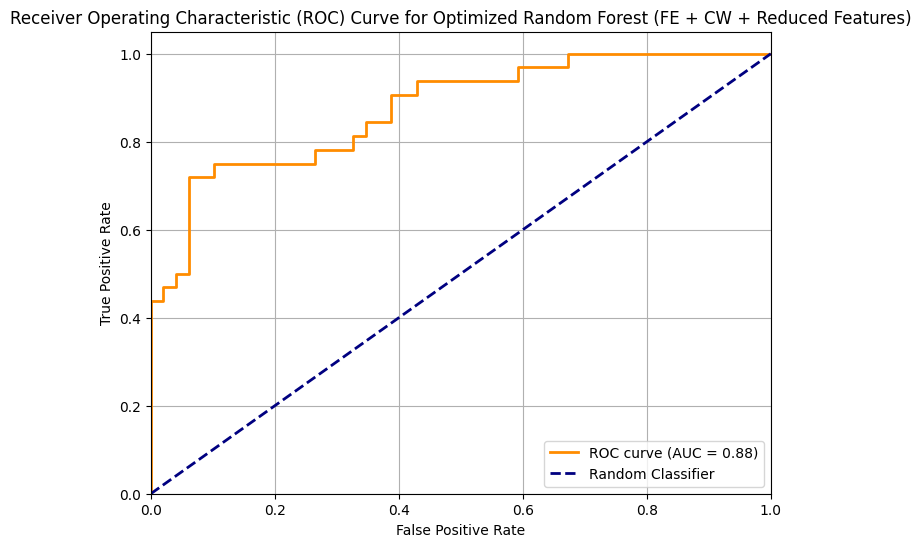

In [31]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class from the reduced feature model
y_pred_proba_rf_reduced = best_rf_model_reduced.predict_proba(X_test_reduced_df)[:, 1]

# Calculate FPR, TPR, and thresholds
fpr_reduced, tpr_reduced, thresholds_reduced = roc_curve(y_test, y_pred_proba_rf_reduced)

# Calculate AUC score
auc_score_reduced = roc_auc_score(y_test, y_pred_proba_rf_reduced)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_reduced, tpr_reduced, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score_reduced:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Optimized Random Forest (FE + CW + Reduced Features)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Feature Importance of Optimized Random Forest Model (Feature Engineered + Class Weight + Reduced Features)

Top 10 Feature Importances (Optimized Random Forest with FE + CW + Reduced):


,Feature,Importance
1,oldpeak,0.192005
4,chest-pain,0.151428
5,thal,0.145299
0,max-heart-rate,0.131226
3,major-vessels,0.115265
6,age thal,0.095013
2,slope,0.087523
7,thal^2,0.082240


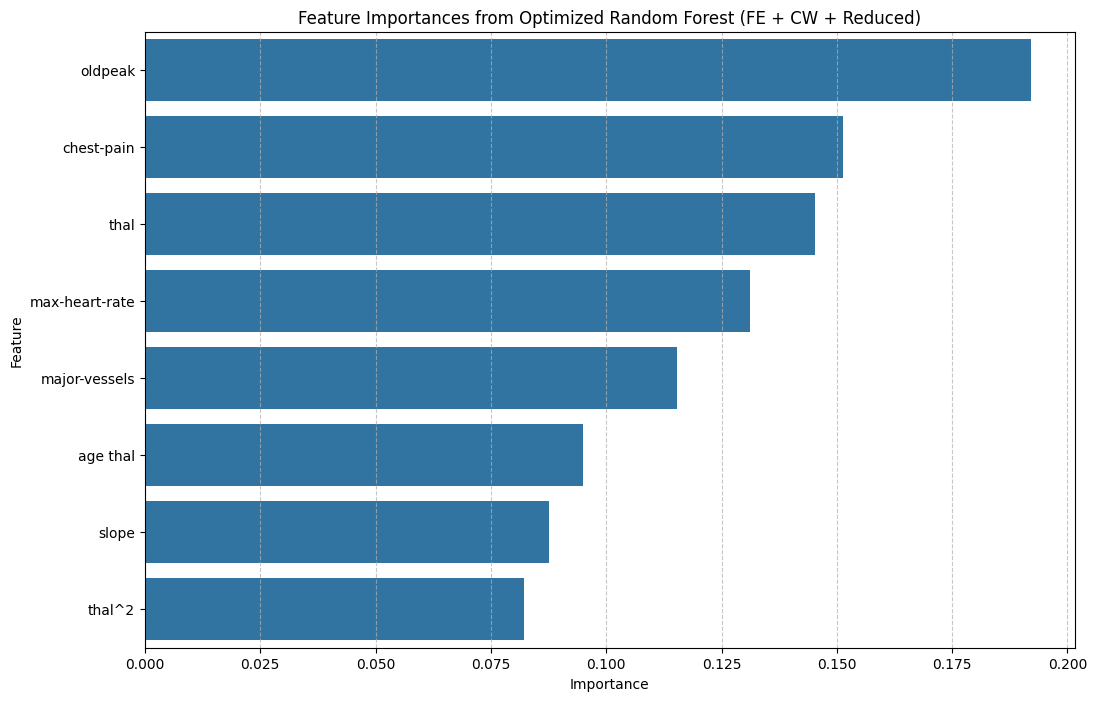

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best Random Forest model (FE + CW + Reduced)
feature_importances_reduced = best_rf_model_reduced.feature_importances_

# Create a DataFrame for better visualization
features_df_reduced = pd.DataFrame({
    'Feature': X_train_reduced_df.columns,
    'Importance': feature_importances_reduced
})

# Sort features by importance
features_df_reduced = features_df_reduced.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances (Optimized Random Forest with FE + CW + Reduced):")
display(features_df_reduced.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df_reduced)
plt.title('Feature Importances from Optimized Random Forest (FE + CW + Reduced)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Save the Optimized Model for Deployment

In [35]:
import joblib

# Define the filename for saving the model
model_filename = 'optimized_random_forest_model.joblib'

# Save the model to a file
joblib.dump(best_rf_model_reduced, model_filename)

print(f"Optimized Random Forest model saved to {model_filename}")

Optimized Random Forest model saved to optimized_random_forest_model.joblib


You can load the model back later using `loaded_model = joblib.load('optimized_random_forest_model.joblib')`